# 🧒 ChildTrack
## Child Companion Matching System (CCMS)
## Model Training Notebook
---
### 📋 Project Overview
An intelligent child safety system that monitors entry and exit points,
matches children with their companions, and triggers alerts when
a child is detected alone or with an unrecognized person.

| Property | Value |
|----------|-------|
| Model | YOLOv8s |
| Classes | child, adult |
| Dataset | KPZ2 (Roboflow) + Mall Dataset + 6 random YouTube clips |
| GPU | Google Colab T4 |
| Training | Initial Training + Fine-tuning |
| Final mAP50 | 0.925 |

### 📋 Notebook Structure
1. Setup & Load Model
2. Train YOLOv8s (v2)
3. Evaluate v2 on Test Set
4. Fine-tuning on Extended Dataset (v4)
5. Test on External Video
6. Save Final Model

---
## Setup & Load Model

In [18]:
!pip install ultralytics roboflow -q

from ultralytics import YOLO
from roboflow import Roboflow
from google.colab import files, drive
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import torch
import glob
import os
# Mount Google Drive
drive.mount('/content/drive')
# Load pre-trained model (v2)
model = YOLO('/content/drive/MyDrive/Colab Notebooks/best.pt')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##  Train YOLOv8s

| Parameter | Value |
|-----------|-------|
| Base Model | yolov8s.pt (ImageNet pretrained) |
| Dataset | KPZ2 — Roboflow (version 1) |
| Epochs | 100 (Early Stopping at 67, best at 52) |
| Batch | 16 |
| Image Size | 640×640 |
| Patience | 15 |
| Optimizer | AdamW (auto) |

In [ ]:
# model = YOLO('yolov8s.pt')

# model.train(
#     data=f'{dataset.location}/data.yaml',
#     epochs=100,
#     imgsz=640,
#     batch=16,
#     patience=15,
#     name='child_adult_v2'
# )

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Child/Adult/Elderly-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=child_adult_v22, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dcf2c5dbbc0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

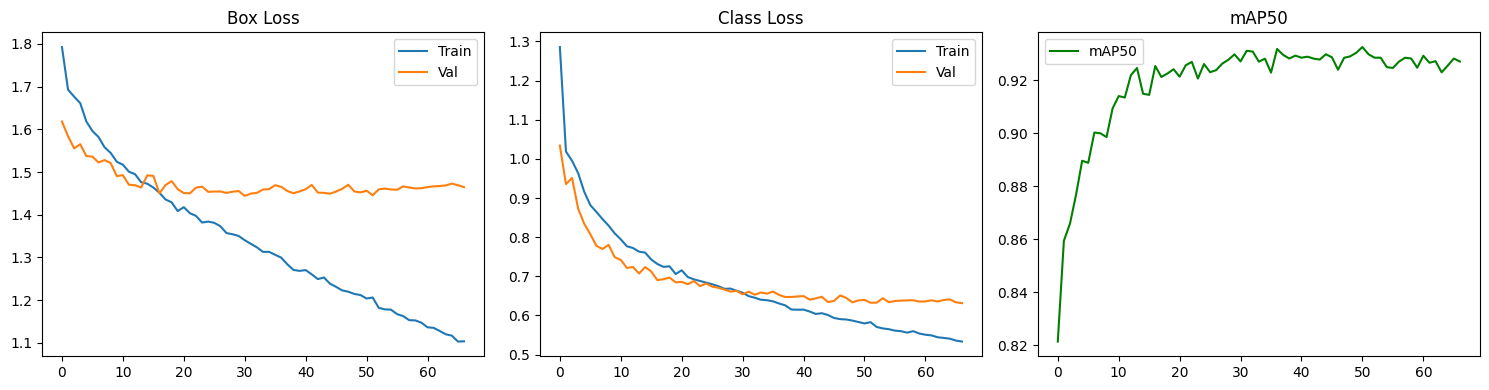

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# results = pd.read_csv('/content/runs/detect/child_adult_v22/results.csv')
# results.columns = results.columns.str.strip()

# plt.figure(figsize=(15,4))

# plt.subplot(1,3,1)
# plt.plot(results['train/box_loss'], label='Train')
# plt.plot(results['val/box_loss'], label='Val')
# plt.title('Box Loss')
# plt.legend()

# plt.subplot(1,3,2)
# plt.plot(results['train/cls_loss'], label='Train')
# plt.plot(results['val/cls_loss'], label='Val')
# plt.title('Class Loss')
# plt.legend()

# plt.subplot(1,3,3)
# plt.plot(results['metrics/mAP50(B)'], color='green', label='mAP50')
# plt.title('mAP50')
# plt.legend()

# plt.tight_layout()
# plt.savefig('results.png', dpi=150)
# plt.show()

# files.download('results.png')

##  Evaluation

In [ ]:
# ─ Evaluate on Test Set ──
metrics = model.val(
    data=f'{dataset.location}/data.yaml',
    split='test'
)

print("=" * 45)
print(" Final Results — Test Set")
print("=" * 45)
print(f"  mAP50:      {metrics.box.map50:.3f}")
print(f"  mAP50-95:   {metrics.box.map:.3f}")
print(f"  Precision:  {metrics.box.p.mean():.3f}")
print(f"  Recall:     {metrics.box.r.mean():.3f}")
print("=" * 45)
print(f"  adult  mAP50: {metrics.box.ap50[0]:.3f}")
print(f"  child  mAP50: {metrics.box.ap50[1]:.3f}")
print("=" * 45)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1939.0±497.1 MB/s, size: 58.4 KB)
val: Scanning /content/Child/Adult/Elderly-1/test/labels.cache... 158 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 158/158 51.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1366, len(boxes) = 2517. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.2it/s 4.5s
                   all        158       2517      0.921      0.884      0.937      0.534
                 adult        152       1576      0.908      0.904      0.936      0.554
                 child        139        941      0.934      0.864      0.938      0.514
Speed: 3.6ms preproc

### Final Evaluation on Test Set

| Metric | Overall | Adult | Child |
|--------|---------|-------|-------|
| mAP50 | 0.937 | 0.936 | 0.938 |
| Precision | 0.921 | 0.908 | 0.934 |
| Recall | 0.884 | 0.904 | 0.864 |
| mAP50-95 | 0.534 | 0.554 | 0.514 |

### 🔍 Key Observations

- **No Overfitting** — Training and validation loss converged smoothly
- **Early Stopping** triggered at epoch 67 (best checkpoint at epoch 52)
- Child detection slightly outperforms adult: mAP50 = **0.938**
- Balanced performance across both classes

### 🎥 Real-Time Testing & Identified Limitations

After training, the model was tested in real time using a live camera.
Overall detection was stable, however the following limitations were observed:

- Small children far from the camera were sometimes **not detected**
- **Motion blur** during walking reduced detection accuracy
- **Partial occlusion** between adult and child caused missed detections

These limitations led to collecting additional data (video frames) and performing Fine-Tuning.

---
##Visual Predictions on Test Images


image 1/158 /content/Child/Adult/Elderly-1/test/images/Tongdosa_20210605_00010_jpg.rf.8bc896e8cd660a658ce61f6e9855bdb9.jpg: 640x640 6 adults, 1 child, 17.3ms
image 2/158 /content/Child/Adult/Elderly-1/test/images/Tongdosa_20210605_00025_jpg.rf.2f6737582934bc26bba9989b4aa2317d.jpg: 640x640 12 adults, 2 childs, 16.1ms
image 3/158 /content/Child/Adult/Elderly-1/test/images/Tongdosa_20210605_00096_jpg.rf.40e6c17b07ecf285ab5de3a44d002f9f.jpg: 640x640 14 adults, 16.1ms
image 4/158 /content/Child/Adult/Elderly-1/test/images/Tongdosa_20210605_00105_jpg.rf.115c7cbb39ceaa602ddae6af8e5862bf.jpg: 640x640 20 adults, 16.1ms
image 5/158 /content/Child/Adult/Elderly-1/test/images/Tongdosa_20210605_00110_jpg.rf.92aaa1fadb382c3fb3c81da0fe54fa1a.jpg: 640x640 19 adults, 1 child, 16.1ms
image 6/158 /content/Child/Adult/Elderly-1/test/images/Tongdosa_20210605_00121_jpg.rf.44d9406c094f923ee2ef05c92bf48a0f.jpg: 640x640 4 adults, 15.4ms
image 7/158 /content/Child/Adult/Elderly-1/test/images/Tongdosa_20210605_

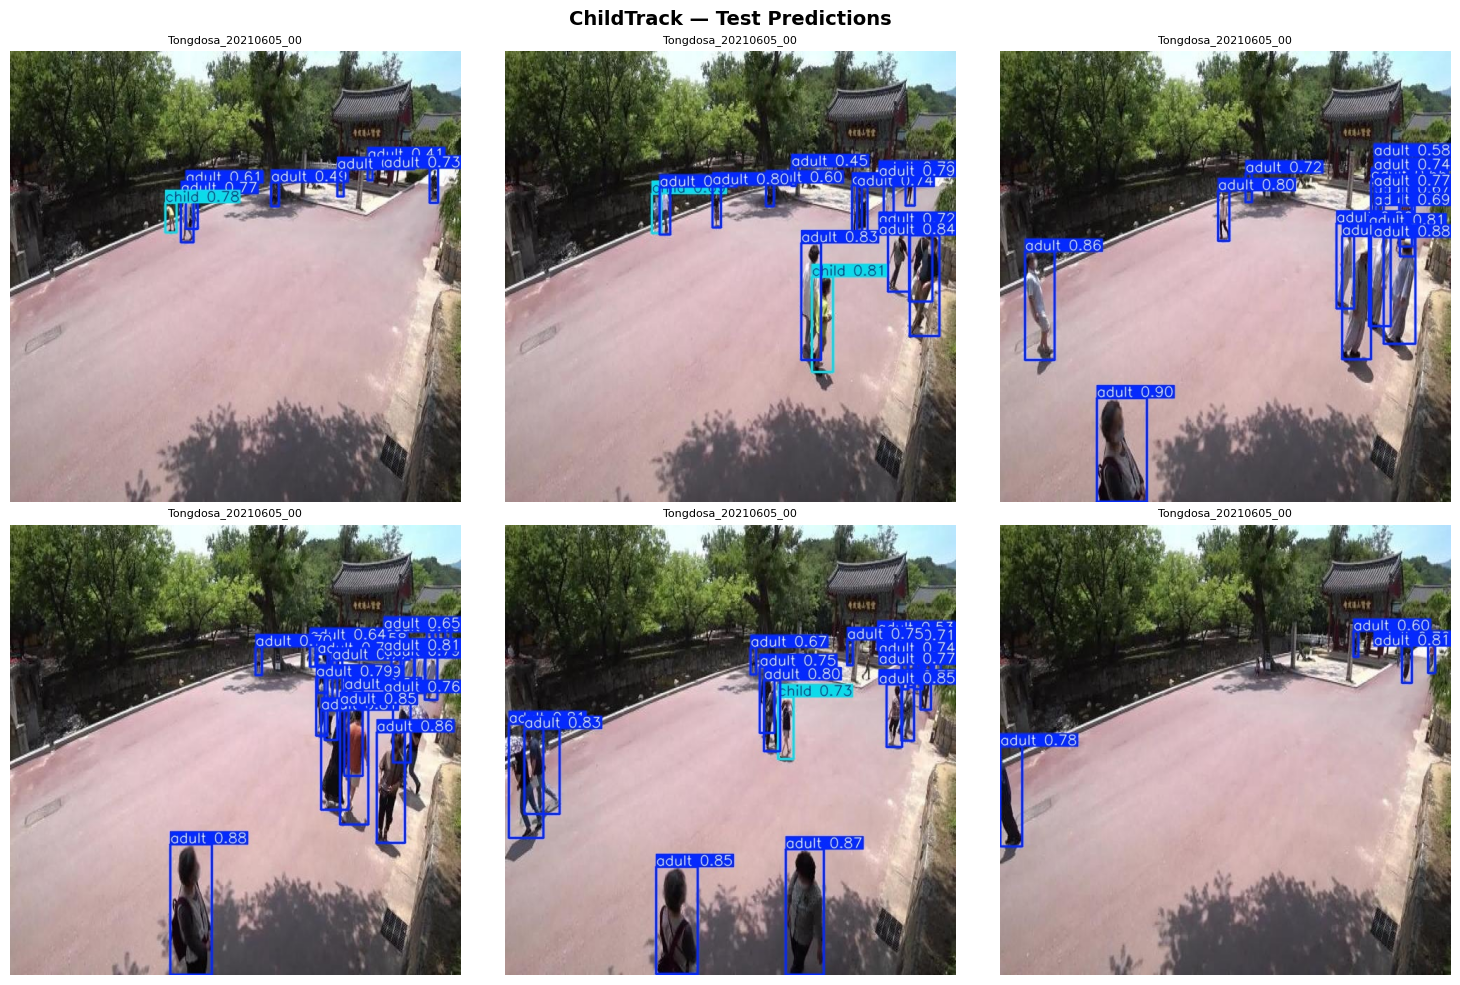

In [ ]:
# ─ Visual Predictions on Test Images ──
from PIL import Image

model.predict(
    source=f'{dataset.location}/test/images/',
    save=True,
    conf=0.4,
    max_det=20,
    name='test_predictions'
)

pred_dir = '/content/runs/detect/test_predictions'
images   = sorted(os.listdir(pred_dir))[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_name in zip(axes.flatten(), images):
    img = Image.open(f"{pred_dir}/{img_name}")
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(img_name[:20], fontsize=8)

plt.suptitle('ChildTrack — Test Predictions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Fine-tuning on Extended Dataset (v4)

Fine-tuning the pre-trained model (mAP50: 0.930) on real mall surveillance footage
and random YouTube clips to improve detection of partially visible and moving persons.

### Why Fine-tuning?

The original model was trained on static images from a Korean playground dataset.
It struggled with:
- Partially visible persons (behind tables, walls)
- Persons at different distances from the camera
- Moving persons in real surveillance footage

### Data Preprocessing — Annotation Normalization

Auto-labeling with SAM3 produced polygon annotations instead of bounding boxes.
A custom script was applied to convert all polygons to bounding boxes before training:
```python
cx = (min(xs) + max(xs)) / 2
cy = (min(ys) + max(ys)) / 2
w  = max(xs) - min(xs)
h  = max(ys) - min(ys)
```

This resolved the YOLOv8 mixed annotation warning and ensured all data was used during training.

### Fine-tuning Configuration

| Parameter | Value | Reason |
|-----------|-------|--------|
| Base Model | best.pt (v2) | Starts from mAP50=0.930 instead of scratch |
| Dataset | Mall Dataset + YouTube clips (version 3) | Real footage with moving persons |
| Epochs | 50 (Early Stopping at 35, best at 25) | Fine-tune needs fewer epochs |
| Batch | 16 | Optimal for T4 GPU |
| Freeze | 5 layers | Preserves core learned features |
| Learning Rate | 0.0005 | 10x smaller than original to avoid overwriting |
| Optimizer | AdamW | Best for fine-tuning tasks |
| Dropout | 0.1 | Prevents overfitting on smaller dataset |
| Patience | 10 | Early stopping if no improvement |

In [ ]:
# ──Load Extended Dataset ──
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ykr4XsonyLKNFhmOHDZq")
project = rf.workspace("shamas-workspace-iwjyj").project("child-adult-elderly-kb8r7")
version = project.version(3)
dataset = version.download("yolov8")



loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Child/Adult/Elderly-3 in yolov8:: 100%|██████████| 23669/23669 [00:07<00:00, 3279.30it/s]


In [20]:
# ──Annotation Normalization (Polygon → Bounding Box) ─
def fix_labels(labels_dir):
    fixed = 0
    for f in os.listdir(labels_dir):
        if not f.endswith('.txt'):
            continue
        path = f'{labels_dir}/{f}'
        with open(path, 'r') as file:
            lines = file.readlines()

        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                new_lines.append(line)
            elif len(parts) > 5:
                cls    = parts[0]
                coords = list(map(float, parts[1:]))
                xs = coords[0::2]
                ys = coords[1::2]
                #cx = sum(xs)/len(xs)
                #cy = sum(ys)/len(ys)
                #w  = max(xs) - min(xs)
                #h  = max(ys) - min(ys)
                cx = (min(xs) + max(xs)) / 2
                cy = (min(ys) + max(ys)) / 2
                w  = max(xs) - min(xs)
                h  = max(ys) - min(ys)
                new_lines.append(
                    f"{cls} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n"
                )
                fixed += 1

        with open(path, 'w') as file:
            file.writelines(new_lines)

    print(f"{fixed} annotation")

for split in ['train', 'valid', 'test']:
    path = f'{dataset.location}/{split}/labels'
    if os.path.exists(path):
        print(f" {split}...")
        fix_labels(path)

 train...
0 annotation
 valid...
0 annotation
 test...
0 annotation


In [7]:
ft_model = YOLO('/content/drive/MyDrive/Colab Notebooks/best.pt')

# Fine-tune
ft_results = ft_model.train(
    data=f'{dataset.location}/data.yaml',

    # ── Training Settings ──
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    name='child_adult_v4',

    # ── Fine-tuning Settings ──
    freeze=5,# Freeze first 10 layers (preserve learned features)
    optimizer='AdamW',
    lr0=0.0005,      # 10x smaller than original training (0.01)
    lrf=0.1,      # Keep LR stable throughout fine-tuning
    dropout=0.1,    # Prevent overfitting on smaller dataset
)

 GPU: Tesla T4
 Dataset: /content/Child/Adult/Elderly-3
 Base Model: best.pt (mAP50=0.930)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Child/Adult/Elderly-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=5, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Colab Notebooks/best.pt, momentum=0.937, mosaic=1.0,

##Test on External Video

In [12]:
!pip install yt-dlp -q

!yt-dlp -o "test_v4.mp4" --format "best[height<=480]" "https://youtu.be/eRxXki-CL-o?si=4t6HI0WsPznLnRin"

model_v4 = YOLO('/content/runs/detect/child_adult_v4/weights/best.pt')

model_v4.predict(
    source='test_v4.mp4',
    save=True,
    conf=0.4,
    name='external_test_v4'
)

import os
pred_dir = '/content/runs/detect/external_test_v4'
for f in os.listdir(pred_dir):
    if f.endswith(('.mp4', '.avi')):
        files.download(f'{pred_dir}/{f}')

[youtube] Extracting URL: https://youtu.be/eRxXki-CL-o?si=4t6HI0WsPznLnRin
[youtube] eRxXki-CL-o: Downloading webpage
[youtube] eRxXki-CL-o: Downloading android vr player API JSON
[info] eRxXki-CL-o: Downloading 1 format(s): 18
[download] test_v4.mp4 has already been downloaded
[download] 100% of    2.82MiB

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1186) /content/test_v4.mp4: 384x640 (no detections), 11.3ms
video 1/1 (frame 2/1186) /content/test_v4.mp4: 384x640 5 adults, 10.5m

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ جاهز


##Save Final Model

In [10]:
files.download('/content/runs/detect/child_adult_v4/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>